In [1]:
import numpy as np
import matplotlib.pyplot as  plt

# Preparing Input Data 

In [2]:
def generate_linear(n=100):   
    import numpy as np
    pts = np.random.uniform(0, 1, (n, 2)  )  # 隨機生成 n 個點，每個點有兩個特徵
    inputs = []
    labels = []     
    for pt in   pts :
        inputs.append([pt[0], pt[1]])
        distance = (pt[0] - pt[1]) / 1.414
        if pt[0] > pt[1]:
            labels.append(0)
        else:
            labels.append(1)
    return np.array(inputs), np.array(labels).reshape(n, 1)

inputs, labels = generate_linear()


#print("Inputs: {} , Labels: {}\n".format(inputs, labels))
print(inputs.shape)
print(labels.shape)
        

(100, 2)
(100, 1)


In [14]:
def generate_XOR_easy():
   # import numpy as np
    inputs = []
    labels = []
    for i in range(11):
        inputs.append([0.1 * i, 0.1 * i])
        labels.append(0)
        if 0.1 * i == 0.5:
            continue
        inputs.append([0.1 * i, 1 - 0.1 * i])
        labels.append(1)
    return np.array(inputs), np.array(labels).reshape(21, 1)

inputs, labels = generate_XOR_easy()
print(inputs.shape)
print(labels.shape)

(21, 2)
(21, 1)


# Activation function

In [4]:
def Sigmoid(x):
    return 1/ (1.0+np.exp(-x))
def Derivative_Sigmoid(x): 
    return x * (1 - x)

In [5]:
def ReLu(x):
    return np.where(x>0,x,0)
def Derivative_ReLu(x):
    return np.where(x>0,1,0)

In [236]:
def tanh(x):
    return np.tanh(x)
def  Derivative_tanh(x):
    return 1 - np.multiply(x, x)

# show result


In [30]:
def show_result(x, y, pred_y):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(14, 7))
    #plotting the ground truth
    plt.subplot(1,2,1,aspect='equal')
    plt.title('Ground truth', fontsize=18)
    for i in range(x.shape[0]):
        if y[i] == 0:
            plt.plot(x[i][0], x[i][1], 'ro') #red 0
        else:
            plt.plot(x[i][0], x[i][1], 'bo') #blue 1

    #plotting predicting
    plt.subplot(1,2,2,aspect='equal')
    plt.text(0, 0, f'Accuracy: {sum(pred_y == y)/y.size}', fontsize = 16, 
         bbox = dict(facecolor = 'white', alpha = 0.5))
    plt.title('Predict result', fontsize=18)
    for i in range(x.shape[0]):
        if pred_y[i] == 0:
            plt.plot(x[i][0], x[i][1], 'ro')
        else:
            plt.plot(x[i][0], x[i][1], 'bo')

In [31]:
def show_result_compare(x, y, predlr1_y,predlr2_y,label1,label2):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(14, 7))
    #plotting the ground truth
    plt.subplot(1,3,1,aspect='equal')
    plt.title('Ground truth', fontsize=18)
    for i in range(x.shape[0]):
        if y[i] == 0:
            plt.plot(x[i][0], x[i][1], 'ro') #red 0
        else:
            plt.plot(x[i][0], x[i][1], 'bo') #blue 1

    #plotting predicting
    plt.subplot(1,3,2,aspect='equal')
    plt.text(0, 0, f'Accuracy: {sum(predlr1_y == y)/y.size}', fontsize = 16, 
         bbox = dict(facecolor = 'white', alpha = 0.5))
    plt.title(label1, fontsize=18)
    for i in range(x.shape[0]):
        if predlr1_y[i] == 0:
            plt.plot(x[i][0], x[i][1], 'ro')
        else:
            plt.plot(x[i][0], x[i][1], 'bo')
            
    #plotting predicting
    plt.subplot(1,3,3,aspect='equal')
    plt.text(0, 0, f'Accuracy: {sum(predlr2_y == y)/y.size}', fontsize = 16, 
         bbox = dict(facecolor = 'white', alpha = 0.5))
    plt.title(label2, fontsize=18)
    for i in range(x.shape[0]):
        if predlr2_y[i] == 0:
            plt.plot(x[i][0], x[i][1], 'ro')
        else:
            plt.plot(x[i][0], x[i][1], 'bo')

In [32]:
def show(x,y):
    print("--------- Training -----------")
    loss_list = []
    epoch_list = []

    plt.title("Learning Curve")
    for epoch in range(1, epochs + 1):
        y_test = model.forward(x)
        loss = model.back_propagation(x, y)
        
        if( (epoch) % 10000 == 0):
            print(f"epoch: {epoch} loss: {loss}")
        #每100更新loss
        if( epoch % 100 == 0):
            loss_list.append(loss)
            epoch_list.append(epoch)
            
    plt.plot(epoch_list, loss_list)
    plt.ylabel('loss', fontsize = 14)
    plt.xlabel('epochs', fontsize = 14)

    # testing
    print("------------- Testing ------------")
    y_pred_probability = model.forward(x)
    print(y_pred_probability)
    # >0.5 -> label 1 <0.5 ->label 0
    y_pred = np.where(y_pred_probability > 0.5, 1, 0)

    print("------------Iteration---------------")

    for i in range(y_pred_probability.size) :
        print(f"Iter:{i+1} |      Ground truth : {y[i]} |   prediction : {y_pred_probability[i]}")
        

    print("---------accuracy----------------------")
    print("accuracy: ", sum(1 for i, j in zip(y, y_pred) if i == j) / len(y) * 100 ,"%")
    
    print("----------Graph-----------------------------")
    show_result(x,y,y_pred)


In [43]:
def compare(x,y,mode1,model2,label1,label2):
    print(f"--------- {label1} Training -----------")
    loss_list = []
    epoch_list = []

    plt.title("Learning Curve")
    for epoch in range(1, epochs + 1):
        y_test = model1.forward(x)
        loss = model1.back_propagation(x, y)
        
        if(epoch % 5000 == 0):
            print(f"epoch: {epoch} loss: {loss}")
        #每100更新loss
        if(epoch % 100 == 0):
            loss_list.append(loss)
            epoch_list.append(epoch)
            
    plt.plot(epoch_list, loss_list, label=label1)
    plt.ylabel('loss', fontsize = 14)
    plt.xlabel('epochs', fontsize = 14)

    # testing
    print(f"-------------{label1} Testing ------------")
    y_pred_probability = model1.forward(x)
    print(y_pred_probability)
    # >0.5 -> label 1 <0.5 ->label 0
    y_pred1 = np.where(y_pred_probability > 0.5, 1, 0)

    print(f"------------{label1} Iteration---------------")

    for i in range(y_pred_probability.size) :
        print(f"Iter:{i+1} |      Ground truth : {y[i]} |   prediction : {y_pred_probability[i]}")
        

    print("---------accuracy----------------------")
    print("accuracy: ", sum(1 for i, j in zip(y, y_pred1) if i == j) / len(y) * 100 ,"%")




    #############################################################################


    # training
    print(f"--------- {label2} Training -----------")
    loss_list = []
    epoch_list = []

    plt.title("Learning Curve")
    for epoch in range(1, epochs + 1):
        y_test = model2.forward(x)
        loss = model2.back_propagation(x, y)
        
        if(epoch % 5000 == 0):
            print(f"epoch: {epoch} loss: {loss}")
        #每100更新loss
        if(epoch % 100 == 0):
            loss_list.append(loss)
            epoch_list.append(epoch)
            


    # testing
    print(f"------------- {label2}Testing ------------")
    y_pred_probability = model2.forward(x)
    print(y_pred_probability)
    # >0.5 -> label 1 <0.5 ->label 0
    y_pred2 = np.where(y_pred_probability > 0.5, 1, 0)

    print(f"------------{label2} Iteration---------------")

    for i in range(y_pred_probability.size) :
        print(f"Iter:{i+1} |      Ground truth : {y[i]} |   prediction : {y_pred_probability[i]}")
        

    print("---------accuracy----------------------")
    print("accuracy: ", sum(1 for i, j in zip(y, y_pred2) if i == j) / len(y) * 100 ,"%")

    print("---------------LR curve---------------")
    plt.plot(epoch_list, loss_list , label=label2)
    plt.legend()
    plt.show()
    
    show_result_compare(x,y,y_pred1,y_pred2,label1,label2)

# Model

In [ ]:
class Model:
    def __init__ (self,input_size=2,hidden1_size=10,hidden2_size=10,output_size=1,
                  learning_rate = 0.1 ,activate = "Sigmoid", optimizer="SGD",decay=0.9):
        # init
        self.input_size = input_size
        self.hidden1_size = hidden1_size
        self.hidden2_size = hidden2_size
        self.output_size = output_size
        self.activate = activate
        self.learning_rate = learning_rate
        self.optimizer = optimizer
        
        #weight bias setting
        self.W1 = np.random.randn(input_size,hidden1_size)
        self.W2 = np.random.randn(hidden1_size,hidden2_size)
        self.W3 = np.random.randn(hidden2_size,output_size)
        
        self.y=()
        
        self.b1 = np.random.randn(1,hidden1_size)/100
        self.b2 = np.random.randn(1,hidden2_size)/100
        self.b3 = np.random.randn(1,output_size)/100
        
        # Define hyperparameters for Momentum optimizer
        self.v_W1 = 0  # Velocity for W1
        self.v_W2 = 0  # Velocity for W2
        self.v_W3 = 0  # Velocity for W3
        self.v_b1 = 0  # Velocity for b1
        self.v_b2 = 0  # Velocity for b2
        self.v_b3 = 0  # Velocity for b3
        self.decay =decay
        
    def forward(self , x)    :
        self.x = x
        #first layer
        
        self.hidden1 = np.dot(x,self.W1) + self.b1
        
        if(self.activate == "Sigmoid") :
            self.hidden1 = Sigmoid(self.hidden1)
        elif(self.activate == "ReLu") :
            self.hidden1 = ReLu(self.hidden1)
        elif(self.activate == "tanh") :
            self.hidden1 = tanh(self.hidden1)
        elif self.activate == "None":
            pass
       
        
        #second layer
        self.hidden2 = np.dot(self.hidden1,self.W2) + self.b2
        
        if(self.activate == "Sigmoid") :
            self.hidden2 = Sigmoid(self.hidden2)
        elif(self.activate == "ReLu") :
            self.hidden2 = ReLu(self.hidden2)
        elif(self.activate == "tanh") :
            self.hidden2 = tanh(self.hidden2)
        elif self.activate == "None":
            pass
        
        
        #output layer
        
        self.y = np.dot(self.hidden2,self.W3) + self.b3
        
        if(self.activate == "Sigmoid") :
            self.y = Sigmoid(self.y)
        elif(self.activate == "ReLu") :
            self.y = ReLu(self.y)
        elif(self.activate == "tanh") :
           self.y = tanh(self.y)
        elif self.activate == "None":
            pass
       
        return self.y
    
    def clip_gradients(self, grad, threshold=1.0):
        grad = np.clip(grad, -threshold, threshold)
        return grad

    def back_propagation(self,x,y_gt):
        #update w3 b3
        y_error =(self.y - y_gt) 
        # error 乘 activation function的導數
        # 算gradient
        if(self.activate == "Sigmoid") :
            grad = y_error * Derivative_Sigmoid(self.y)
        elif(self.activate == "ReLu") :
            grad = y_error * Derivative_ReLu(self.y)
        elif(self.activate == "tanh") :
            grad = y_error * Derivative_tanh(self.y)
        elif self.activate == "None":
            grad=y_error
            
        grad = self.clip_gradients(grad)
            
        if(self.optimizer == "SGD"):
            #update
            self.W3 -= self.learning_rate * np.dot(self.hidden2.T,grad)
            self.b3 -= self.learning_rate * np.sum(grad,axis=0)
        elif(self.optimizer == "Momentum"):
            self.v_W3 = self.decay *self.v_W3 + self.learning_rate * np.dot(self.hidden2.T,grad)
            self.v_b3 =self.decay *self.v_b3 + self.learning_rate * np.sum(grad,axis=0)
            self.W3 -= self.v_W3
            self.b3 -= self.b3
            
            #update w2 b2
        hidden2_error = np.dot(grad,self.W3.T)
        if(self.activate == "Sigmoid") :
            grad = hidden2_error * Derivative_Sigmoid(self.hidden2)
        elif(self.activate == "ReLu") :
            grad = hidden2_error * Derivative_ReLu(self.hidden2)
        elif(self.activate == "tanh") :
            grad = hidden2_error * Derivative_tanh(self.hidden2)
        elif self.activate == "None":
            grad=hidden2_error
            
        grad = self.clip_gradients(grad)
            
        #update
        if(self.optimizer == "SGD"):
            self.W2 -= self.learning_rate * np.dot(self.hidden1.T,grad)
            self.b2 -= self.learning_rate * np.sum(grad,axis=0)
        elif(self.optimizer == "Momentum"):
            self.v_W2 = self.decay *self.v_W2 + self.learning_rate * np.dot(self.hidden1.T,grad)
            self.v_b2 =self.decay *self.v_b2 + self.learning_rate * np.sum(grad,axis=0)
            self.W2 -= self.v_W2
            self.b2 -= self.b2
        #update w1 b1
        hidden1_error = np.dot(grad,self.W2.T)
        if(self.activate == "Sigmoid") :
            grad = hidden1_error * Derivative_Sigmoid(self.hidden1)
        elif(self.activate == "ReLu") :
            grad = hidden1_error * Derivative_ReLu(self.hidden1)
        elif(self.activate == "tanh") :
            grad = hidden1_error* Derivative_tanh(self.hidden1)
        elif self.activate == "None":
            grad = hidden1_error
            
        grad = self.clip_gradients(grad)
            
        #update
        if(self.optimizer == "SGD"):
            self.W1 -= self.learning_rate * np.dot(x.T,grad)
            self.b1 -= self.learning_rate * np.sum(grad,axis=0)
        elif(self.optimizer == "Momentum"):
            self.v_W1 = self.decay *self.v_W1 + self.learning_rate * np.dot(x.T,grad)
            self.v_b1 =self.decay *self.v_b1 + self.learning_rate * np.sum(grad,axis=0)
            self.W1 -= self.v_W1
            self.b1 -= self.b1
        
        return  np.sum ((self.y-y_gt) ** 2)/self.y.shape[0]  
    
        
            

# Train 

## Linear Data

--------- Training -----------
epoch: 0 loss: 0.23899275404870948
epoch: 10000 loss: 0.0035392500976320585
epoch: 20000 loss: 0.001991801278261678
epoch: 30000 loss: 0.0012670714877540418
epoch: 40000 loss: 0.0008434497676660948
epoch: 50000 loss: 0.0005894213156526365
epoch: 60000 loss: 0.0004317985576368198
epoch: 70000 loss: 0.0003296211793266983
epoch: 80000 loss: 0.0002604068549407383
epoch: 90000 loss: 0.0002116074373707616
epoch: 100000 loss: 0.00017597901326402808
------------- Testing ------------
[[5.30971891e-10]
 [9.99391449e-01]
 [1.00000000e+00]
 [9.99662056e-01]
 [2.06723347e-09]
 [1.00000000e+00]
 [9.99999995e-01]
 [1.00000000e+00]
 [3.47787824e-10]
 [4.49557768e-10]
 [9.99999998e-01]
 [2.89485352e-08]
 [2.75559796e-08]
 [3.73302392e-10]
 [1.00000000e+00]
 [1.00000000e+00]
 [9.18068205e-01]
 [3.79562807e-10]
 [1.00000000e+00]
 [2.28300656e-07]
 [1.00000000e+00]
 [9.99999996e-01]
 [6.69561724e-10]
 [1.00000000e+00]
 [1.00000000e+00]
 [2.28341405e-09]
 [9.86923991e-01]
 [

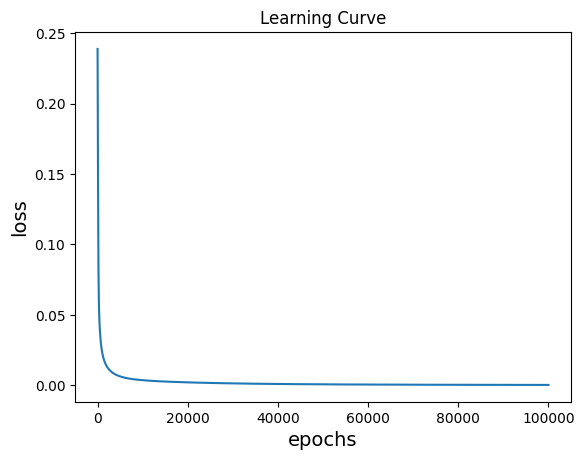

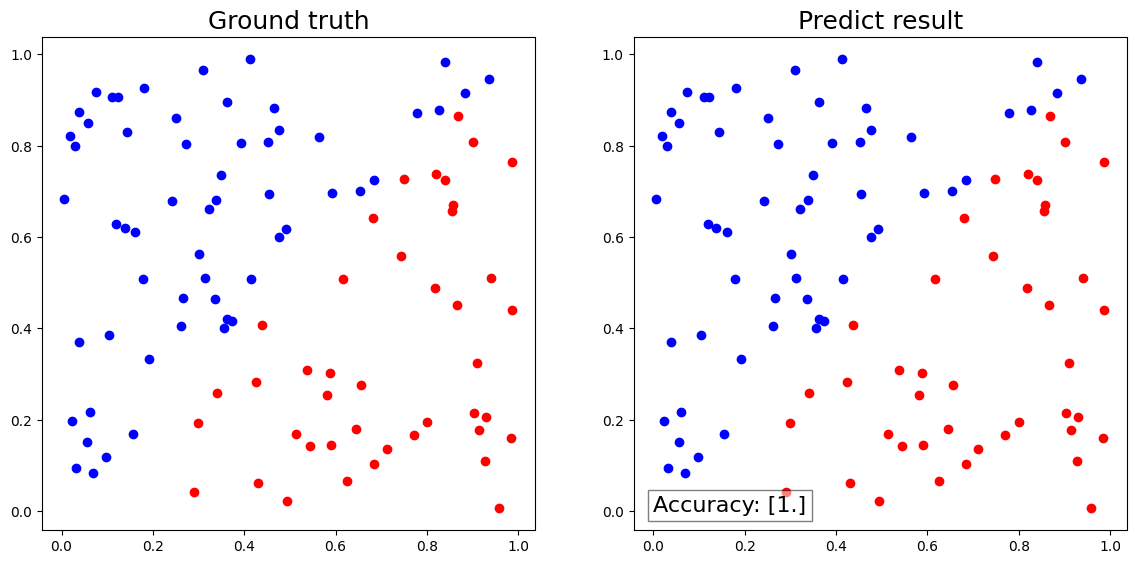

In [356]:
x,y =generate_linear()
epochs = 100001 
model = Model()
# training
show(x,y)


## XOR data

--------- Training -----------
epoch: 10000 loss: 0.05751668788090057
epoch: 20000 loss: 0.01474494301341855
epoch: 30000 loss: 0.0040182786458902425
epoch: 40000 loss: 0.0016822799830555376
epoch: 50000 loss: 0.0009479909840432841
epoch: 60000 loss: 0.0006273857630376627
epoch: 70000 loss: 0.00045652561454417417
epoch: 80000 loss: 0.00035317661958216343
epoch: 90000 loss: 0.0002850433004171985
epoch: 100000 loss: 0.00023726020545850962
------------- Testing ------------
[[4.80435049e-03]
 [9.99837065e-01]
 [7.77927896e-04]
 [9.99828571e-01]
 [5.46219440e-04]
 [9.99806841e-01]
 [1.47595974e-03]
 [9.99659411e-01]
 [1.41626078e-02]
 [9.65147397e-01]
 [4.49273381e-02]
 [1.64540480e-02]
 [9.64839088e-01]
 [3.56636761e-03]
 [9.99633512e-01]
 [1.24065883e-03]
 [9.99787415e-01]
 [6.85388539e-04]
 [9.99799195e-01]
 [4.91770191e-04]
 [9.99794944e-01]]
------------Iteration---------------
Iter:1 |      Ground truth : [0] |   prediction : [0.00480435]
Iter:2 |      Ground truth : [1] |   predicti

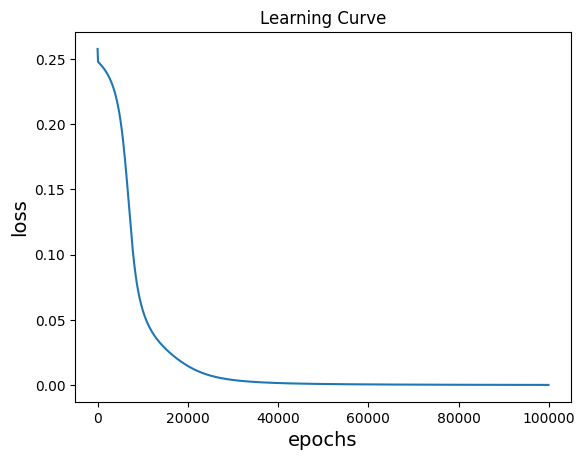

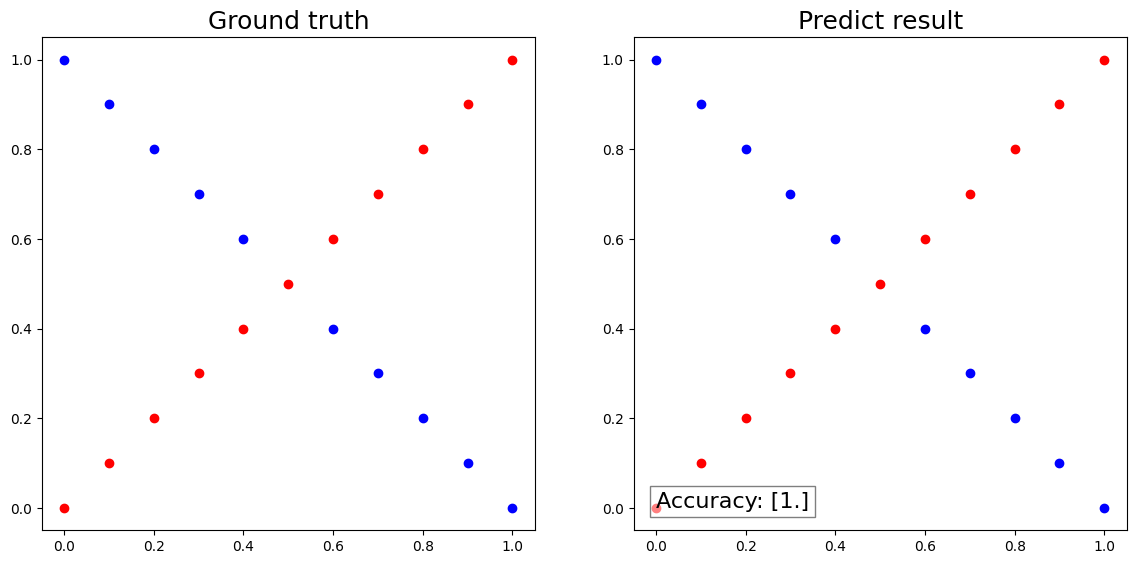

In [358]:
X_xor,Y_xor =generate_XOR_easy()

epochs = 100000
model = Model()
# training
show(X_xor,Y_xor)

# Discussion

## Differnet LR

### Linear Data

--------- lr=0.001 Training -----------
epoch: 0 loss: 0.46626598103925543
-------------lr=0.001 Testing ------------
[[0.91742259]
 [0.93589672]
 [0.17948944]
 [0.95510126]
 [0.0054484 ]
 [0.96501709]
 [0.02348067]
 [0.09139947]
 [0.01945763]
 [0.08570874]
 [0.03191204]
 [0.85713026]
 [0.00735152]
 [0.10521113]
 [0.03729164]
 [0.02562499]
 [0.948292  ]
 [0.96891569]
 [0.0113318 ]
 [0.16980883]
 [0.98781173]
 [0.01834996]
 [0.13239756]
 [0.09438136]
 [0.69909505]
 [0.0499094 ]
 [0.01573595]
 [0.00785743]
 [0.9351618 ]
 [0.89645115]
 [0.00777869]
 [0.98260997]
 [0.93583283]
 [0.02401471]
 [0.00498995]
 [0.52648328]
 [0.21345436]
 [0.95644005]
 [0.99429046]
 [0.69811665]
 [0.31525772]
 [0.9851921 ]
 [0.09533282]
 [0.81244931]
 [0.45763759]
 [0.75225698]
 [0.97079686]
 [0.29219612]
 [0.98641648]
 [0.22246027]
 [0.05705813]
 [0.98825636]
 [0.09619893]
 [0.00829685]
 [0.01973166]
 [0.14432409]
 [0.43929605]
 [0.95787815]
 [0.99156696]
 [0.55510631]
 [0.17178986]
 [0.01950822]
 [0.01113562]


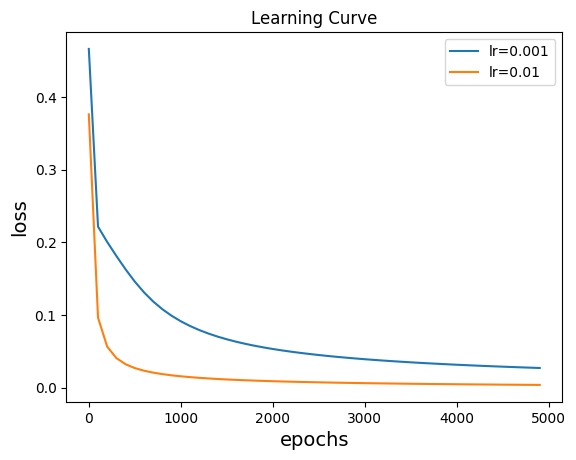

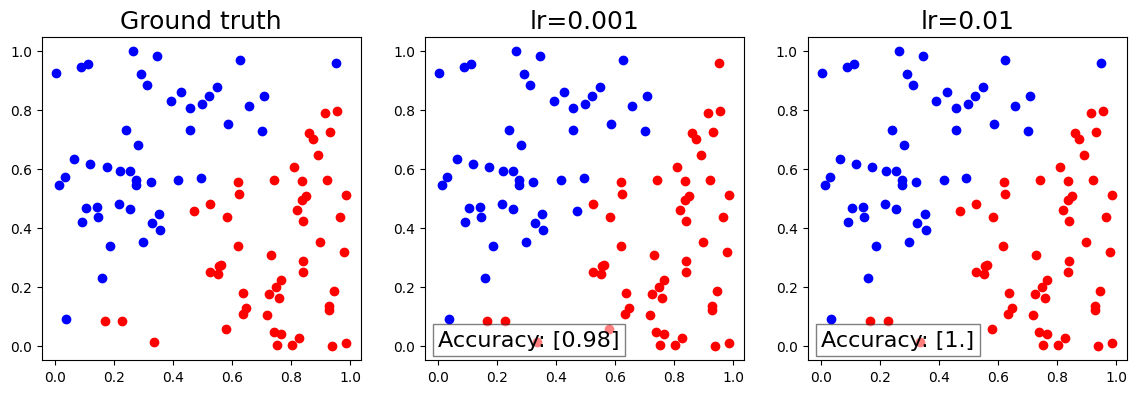

In [370]:
x,y =generate_linear()
epochs = 5000
model1  = Model(learning_rate=0.001)
model2 = Model(learning_rate=0.01)
# training

compare(x,y,model1,model2,"lr=0.001","lr=0.01")



### XOR Data

--------- lr=0.001 Training -----------
epoch: 0 loss: 0.3038692087850037
-------------lr=0.001 Testing ------------
[[0.89752137]
 [0.92601998]
 [0.19651381]
 [0.94068688]
 [0.00702918]
 [0.95492135]
 [0.03059694]
 [0.12151634]
 [0.02522027]
 [0.09953932]
 [0.04089521]
 [0.84252194]
 [0.00960439]
 [0.12430772]
 [0.04662991]
 [0.03263897]
 [0.93431007]
 [0.95959986]
 [0.01490471]
 [0.18569936]
 [0.98401051]
 [0.02374317]
 [0.14836442]
 [0.11165148]
 [0.68618977]
 [0.06065444]
 [0.02046853]
 [0.01026477]
 [0.92160123]
 [0.87573353]
 [0.01015273]
 [0.97594702]
 [0.92045738]
 [0.03179202]
 [0.00642401]
 [0.51647556]
 [0.228641  ]
 [0.94432566]
 [0.99227073]
 [0.67262095]
 [0.36849216]
 [0.9799908 ]
 [0.11125374]
 [0.7886596 ]
 [0.47115691]
 [0.73641972]
 [0.96142277]
 [0.30096545]
 [0.98140185]
 [0.23868837]
 [0.06862466]
 [0.98416947]
 [0.11371414]
 [0.01088171]
 [0.02552707]
 [0.15968986]
 [0.43614568]
 [0.94755717]
 [0.98882132]
 [0.54495   ]
 [0.18666883]
 [0.02533848]
 [0.01464373]
 

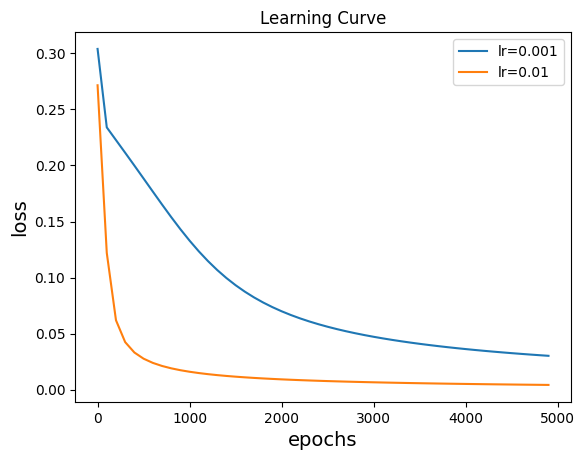

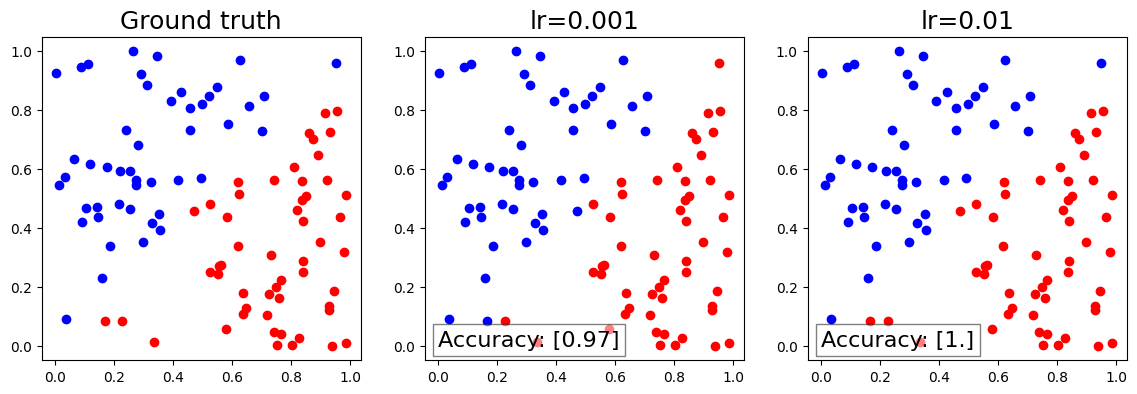

In [371]:
x_xor,y_xor =generate_XOR_easy()
epochs = 5000
model1  = Model(learning_rate=0.001)
model2 = Model(learning_rate=0.01)
# training
compare(x,y,model1,model2,"lr=0.001","lr=0.01")


## Different hidden layer (2 vs 4)

In [10]:
class Model1:
    def __init__ (self,input_size=2,hidden1_size=5,hidden2_size=5,hidden3_size=5,hidden4_size=5,output_size=1,learning_rate = 0.0001 ,activate = "Sigmoid"):
        # init
        self.input_size = input_size
        self.hidden1_size = hidden1_size
        self.hidden2_size = hidden2_size
        self.hidden3_size = hidden3_size
        self.hidden4_size = hidden4_size
        self.output_size = output_size
        self.activate = activate
        self.learning_rate = learning_rate
        #weight bias setting
        
        self.W1 = np.random.rand(input_size,hidden1_size)
        self.W2 = np.random.rand(hidden1_size,hidden2_size)
        self.W3 = np.random.rand(hidden2_size,hidden3_size)
        self.W4 = np.random.rand(hidden3_size,hidden4_size)
        self.W5 = np.random.rand(hidden4_size,output_size)
        
        self.y=()
        
        self.b1 = 0.001
        self.b2 = 0.001
        self.b3 = 0.001
        self.b4 = 0.001
        self.b5 = 0.001
        
    def forward(self , x) :
        self.x = x
        #first layer
        
        self.hidden1 = np.dot(x,self.W1) + self.b1
        
        if(self.activate == "Sigmoid") :
            self.hidden1 = Sigmoid(self.hidden1)
        elif(self.activate == "ReLu") :
            self.hidden1 = ReLu(self.hidden1)
        elif(self.activate == "tanh") :
            self.hidden1 = tanh(self.hidden1)
        
       
        
        #second layer
        self.hidden2 = np.dot(self.hidden1,self.W2) + self.b2
        
        if(self.activate == "Sigmoid") :
            self.hidden2 = Sigmoid(self.hidden2)
        elif(self.activate == "ReLu") :
            self.hidden2 = ReLu(self.hidden2)
        elif(self.activate == "tanh") :
            self.hidden2 = tanh(self.hidden2)
            
        #third layer
        self.hidden3 = np.dot(self.hidden2,self.W3) + self.b3
        
        if(self.activate == "Sigmoid") :
            self.hidden3 = Sigmoid(self.hidden3)
        elif(self.activate == "ReLu") :
            self.hidden3= ReLu(self.hidden3)
        elif(self.activate == "tanh") :
            self.hidden3 = tanh(self.hidden3)
        
        #fourth layer
        self.hidden4 = np.dot(self.hidden3,self.W4) + self.b4
        
        if(self.activate == "Sigmoid") :
            self.hidden4 = Sigmoid(self.hidden4)
        elif(self.activate == "ReLu") :
            self.hidden4 = ReLu(self.hidden4)
        elif(self.activate == "tanh") :
            self.hidden4 = tanh(self.hidden4)
        
        #output layer
        
        self.y = np.dot(self.hidden4,self.W5) + self.b5
        
        if(self.activate == "Sigmoid") :
            self.y = Sigmoid(self.y)
        elif(self.activate == "ReLu") :
            self.y = ReLu(self.y)
        elif(self.activate == "tanh") :
           self.y = tanh(self.y)
        
       
        return self.y
    
    def back_propagation(self, x, y_gt):
        # output layer error
        y_error = self.y - y_gt
        if self.activate == "Sigmoid":
            temp = y_error * Derivative_Sigmoid(self.y)
        elif self.activate == "ReLu":
            temp = y_error * Derivative_ReLu(self.y)
        elif self.activate == "tanh":
            temp = y_error * Derivative_tanh(self.y)
        
        # update W5 and b5
        self.W5 -= self.learning_rate * np.dot(self.hidden4.T, temp)
        self.b5 -= self.learning_rate * temp

        # hidden4 layer error
        hidden4_error = np.dot(temp, self.W5.T)
        if self.activate == "Sigmoid":
            temp = hidden4_error * Derivative_Sigmoid(self.hidden4)
        elif self.activate == "ReLu":
            temp = hidden4_error * Derivative_ReLu(self.hidden4)
        elif self.activate == "tanh":
            temp = hidden4_error * Derivative_tanh(self.hidden4)
        
        # update W4 and b4
        self.W4 -= self.learning_rate * np.dot(self.hidden3.T, temp)
        self.b4 -= self.learning_rate * temp

        # hidden3 layer error
        hidden3_error = np.dot(temp, self.W4.T)
        if self.activate == "Sigmoid":
            temp = hidden3_error * Derivative_Sigmoid(self.hidden3)
        elif self.activate == "ReLu":
            temp = hidden3_error * Derivative_ReLu(self.hidden3)
        elif self.activate == "tanh":
            temp = hidden3_error * Derivative_tanh(self.hidden3)
        
        # update W3 and b3
        self.W3 -= self.learning_rate * np.dot(self.hidden2.T, temp)
        self.b3 -= self.learning_rate * temp

        # hidden2 layer error
        hidden2_error = np.dot(temp, self.W3.T)
        if self.activate == "Sigmoid":
            temp = hidden2_error * Derivative_Sigmoid(self.hidden2)
        elif self.activate == "ReLu":
            temp = hidden2_error * Derivative_ReLu(self.hidden2)
        elif self.activate == "tanh":
            temp = hidden2_error * Derivative_tanh(self.hidden2)
        
        # update W2 and b2
        self.W2 -= self.learning_rate * np.dot(self.hidden1.T, temp)
        self.b2 -= self.learning_rate * temp

        # hidden1 layer error
        hidden1_error = np.dot(temp, self.W2.T)
        if self.activate == "Sigmoid":
            temp = hidden1_error * Derivative_Sigmoid(self.hidden1)
        elif self.activate == "ReLu":
            temp = hidden1_error * Derivative_ReLu(self.hidden1)
        elif self.activate == "tanh":
            temp = hidden1_error * Derivative_tanh(self.hidden1)
        
        # update W1 and b1
        self.W1 -= self.learning_rate * np.dot(x.T, temp)
        self.b1 -= self.learning_rate * temp
    
        return  np.sum ((self.y-y_gt) ** 2)/self.y.shape[1]

In [24]:
class Model_4layer:
    def __init__(self, input_size=2, hidden1_size=10, hidden2_size=10, hidden3_size=10, hidden4_size=10, output_size=1, learning_rate=0.1, activate="Sigmoid"):
        # init
        self.input_size = input_size
        self.hidden1_size = hidden1_size
        self.hidden2_size = hidden2_size
        self.hidden3_size = hidden3_size
        self.hidden4_size = hidden4_size
        self.output_size = output_size
        self.activate = activate
        self.learning_rate = learning_rate
        
        # weight and bias initialization
        self.W1 = np.random.randn(input_size, hidden1_size)
        self.W2 = np.random.randn(hidden1_size, hidden2_size)
        self.W3 = np.random.randn(hidden2_size, hidden3_size)
        self.W4 = np.random.randn(hidden3_size, hidden4_size)
        self.W5 = np.random.randn(hidden4_size, output_size)
        
        self.b1 = np.random.randn(1, hidden1_size) / 100
        self.b2 = np.random.randn(1, hidden2_size) / 100
        self.b3 = np.random.randn(1, hidden3_size) / 100
        self.b4 = np.random.randn(1, hidden4_size) / 100
        self.b5 = np.random.randn(1, output_size) / 100
    
    def forward(self, x):
        self.x = x
        
        # First hidden layer
        self.hidden1 = np.dot(x, self.W1) + self.b1
        if self.activate == "Sigmoid":
            self.hidden1 = Sigmoid(self.hidden1)
        elif self.activate == "ReLu":
            self.hidden1 = ReLu(self.hidden1)
        elif self.activate == "tanh":
            self.hidden1 = tanh(self.hidden1)
        
        # Second hidden layer
        self.hidden2 = np.dot(self.hidden1, self.W2) + self.b2
        if self.activate == "Sigmoid":
            self.hidden2 = Sigmoid(self.hidden2)
        elif self.activate == "ReLu":
            self.hidden2 = ReLu(self.hidden2)
        elif self.activate == "tanh":
            self.hidden2 = tanh(self.hidden2)
        
        # Third hidden layer
        self.hidden3 = np.dot(self.hidden2, self.W3) + self.b3
        if self.activate == "Sigmoid":
            self.hidden3 = Sigmoid(self.hidden3)
        elif self.activate == "ReLu":
            self.hidden3 = ReLu(self.hidden3)
        elif self.activate == "tanh":
            self.hidden3 = tanh(self.hidden3)
        
        # Fourth hidden layer
        self.hidden4 = np.dot(self.hidden3, self.W4) + self.b4
        if self.activate == "Sigmoid":
            self.hidden4 = Sigmoid(self.hidden4)
        elif self.activate == "ReLu":
            self.hidden4 = ReLu(self.hidden4)
        elif self.activate == "tanh":
            self.hidden4 = tanh(self.hidden4)
        
        # Output layer
        self.y = np.dot(self.hidden4, self.W5) + self.b5
        if self.activate == "Sigmoid":
            self.y = Sigmoid(self.y)
        elif self.activate == "ReLu":
            self.y = ReLu(self.y)
        elif self.activate == "tanh":
            self.y = tanh(self.y)
        
        return self.y
    
    def clip_gradients(self, grad, threshold=1.0):
        grad = np.clip(grad, -threshold, threshold)
        return grad
    
    def back_propagation(self, x, y_gt):
        # Update W5 and b5
        y_error = (self.y - y_gt)
        if self.activate == "Sigmoid":
            grad = y_error * Derivative_Sigmoid(self.y)
        elif self.activate == "ReLu":
            grad = y_error * Derivative_ReLu(self.y)
        elif self.activate == "tanh":
            grad = y_error * Derivative_tanh(self.y)
        grad = self.clip_gradients(grad)
        
        self.W5 -= self.learning_rate * np.dot(self.hidden4.T, grad)
        self.b5 -= self.learning_rate * np.sum(grad, axis=0)
        
        # Update W4 and b4
        hidden4_error = np.dot(grad, self.W5.T)
        if self.activate == "Sigmoid":
            grad = hidden4_error * Derivative_Sigmoid(self.hidden4)
        elif self.activate == "ReLu":
            grad = hidden4_error * Derivative_ReLu(self.hidden4)
        elif self.activate == "tanh":
            grad = hidden4_error * Derivative_tanh(self.hidden4)
        grad = self.clip_gradients(grad)
        
        self.W4 -= self.learning_rate * np.dot(self.hidden3.T, grad)
        self.b4 -= self.learning_rate * np.sum(grad, axis=0)
        
        # Update W3 and b3
        hidden3_error = np.dot(grad, self.W4.T)
        if self.activate == "Sigmoid":
            grad = hidden3_error * Derivative_Sigmoid(self.hidden3)
        elif self.activate == "ReLu":
            grad = hidden3_error * Derivative_ReLu(self.hidden3)
        elif self.activate == "tanh":
            grad = hidden3_error * Derivative_tanh(self.hidden3)
        grad = self.clip_gradients(grad)
        
        self.W3 -= self.learning_rate * np.dot(self.hidden2.T, grad)
        self.b3 -= self.learning_rate * np.sum(grad, axis=0)
        
        # Update W2 and b2
        hidden2_error = np.dot(grad, self.W3.T)
        if self.activate == "Sigmoid":
            grad = hidden2_error * Derivative_Sigmoid(self.hidden2)
        elif self.activate == "ReLu":
            grad = hidden2_error * Derivative_ReLu(self.hidden2)
        elif self.activate == "tanh":
            grad = hidden2_error * Derivative_tanh(self.hidden2)
        grad = self.clip_gradients(grad)
        
        self.W2 -= self.learning_rate * np.dot(self.hidden1.T, grad)
        self.b2 -= self.learning_rate * np.sum(grad, axis=0)
        
        # Update W1 and b1
        hidden1_error = np.dot(grad, self.W2.T)
        if self.activate == "Sigmoid":
            grad = hidden1_error * Derivative_Sigmoid(self.hidden1)
        elif self.activate == "ReLu":
            grad = hidden1_error * Derivative_ReLu(self.hidden1)
        elif self.activate == "tanh":
            grad = hidden1_error * Derivative_tanh(self.hidden1)
        grad = self.clip_gradients(grad)
        
        self.W1 -= self.learning_rate * np.dot(x.T, grad)
        self.b1 -= self.learning_rate * np.sum(grad, axis=0)
    
        return np.sum((self.y - y_gt) ** 2) / self.y.shape[0]

In [ ]:
class Model1:
    def __init__ (self,input_size=2,hidden1_size=5,hidden2_size=5,hidden3_size=5,hidden4_size=5,output_size=1,learning_rate = 0.0001 ,activate = "Sigmoid"):
        # init
        self.input_size = input_size
        self.hidden1_size = hidden1_size
        self.hidden2_size = hidden2_size
        self.hidden3_size = hidden3_size
        self.hidden4_size = hidden4_size
        self.output_size = output_size
        self.activate = activate
        self.learning_rate = learning_rate
        #weight bias setting
        
        self.W1 = np.random.rand(input_size,hidden1_size)
        self.W2 = np.random.rand(hidden1_size,hidden2_size)
        self.W3 = np.random.rand(hidden2_size,hidden3_size)
        self.W4 = np.random.rand(hidden3_size,hidden4_size)
        self.W5 = np.random.rand(hidden4_size,output_size)
        
        self.y=()
        
        self.b1 = 0.001
        self.b2 = 0.001
        self.b3 = 0.001
        self.b4 = 0.001
        self.b5 = 0.001
        
    def forward(self , x) :
        self.x = x
        #first layer
        
        self.hidden1 = np.dot(x,self.W1) + self.b1
        
        if(self.activate == "Sigmoid") :
            self.hidden1 = Sigmoid(self.hidden1)
        elif(self.activate == "ReLu") :
            self.hidden1 = ReLu(self.hidden1)
        elif(self.activate == "tanh") :
            self.hidden1 = tanh(self.hidden1)
        
       
        
        #second layer
        self.hidden2 = np.dot(self.hidden1,self.W2) + self.b2
        
        if(self.activate == "Sigmoid") :
            self.hidden2 = Sigmoid(self.hidden2)
        elif(self.activate == "ReLu") :
            self.hidden2 = ReLu(self.hidden2)
        elif(self.activate == "tanh") :
            self.hidden2 = tanh(self.hidden2)
            
        #third layer
        self.hidden3 = np.dot(self.hidden2,self.W3) + self.b3
        
        if(self.activate == "Sigmoid") :
            self.hidden3 = Sigmoid(self.hidden3)
        elif(self.activate == "ReLu") :
            self.hidden3= ReLu(self.hidden3)
        elif(self.activate == "tanh") :
            self.hidden3 = tanh(self.hidden3)
        
        #fourth layer
        self.hidden4 = np.dot(self.hidden3,self.W4) + self.b4
        
        if(self.activate == "Sigmoid") :
            self.hidden4 = Sigmoid(self.hidden4)
        elif(self.activate == "ReLu") :
            self.hidden4 = ReLu(self.hidden4)
        elif(self.activate == "tanh") :
            self.hidden4 = tanh(self.hidden4)
        
        #output layer
        
        self.y = np.dot(self.hidden4,self.W5) + self.b5
        
        if(self.activate == "Sigmoid") :
            self.y = Sigmoid(self.y)
        elif(self.activate == "ReLu") :
            self.y = ReLu(self.y)
        elif(self.activate == "tanh") :
           self.y = tanh(self.y)
        
       
        return self.y
    
    def back_propagation(self, x, y_gt):
        # output layer error
        y_error = self.y - y_gt
        if self.activate == "Sigmoid":
            temp = y_error * Derivative_Sigmoid(self.y)
        elif self.activate == "ReLu":
            temp = y_error * Derivative_ReLu(self.y)
        elif self.activate == "tanh":
            temp = y_error * Derivative_tanh(self.y)
        
        # update W5 and b5
        self.W5 -= self.learning_rate * np.dot(self.hidden4.T, temp)
        self.b5 -= self.learning_rate * temp

        # hidden4 layer error
        hidden4_error = np.dot(temp, self.W5.T)
        if self.activate == "Sigmoid":
            temp = hidden4_error * Derivative_Sigmoid(self.hidden4)
        elif self.activate == "ReLu":
            temp = hidden4_error * Derivative_ReLu(self.hidden4)
        elif self.activate == "tanh":
            temp = hidden4_error * Derivative_tanh(self.hidden4)
        
        # update W4 and b4
        self.W4 -= self.learning_rate * np.dot(self.hidden3.T, temp)
        self.b4 -= self.learning_rate * temp

        # hidden3 layer error
        hidden3_error = np.dot(temp, self.W4.T)
        if self.activate == "Sigmoid":
            temp = hidden3_error * Derivative_Sigmoid(self.hidden3)
        elif self.activate == "ReLu":
            temp = hidden3_error * Derivative_ReLu(self.hidden3)
        elif self.activate == "tanh":
            temp = hidden3_error * Derivative_tanh(self.hidden3)
        
        # update W3 and b3
        self.W3 -= self.learning_rate * np.dot(self.hidden2.T, temp)
        self.b3 -= self.learning_rate * temp

        # hidden2 layer error
        hidden2_error = np.dot(temp, self.W3.T)
        if self.activate == "Sigmoid":
            temp = hidden2_error * Derivative_Sigmoid(self.hidden2)
        elif self.activate == "ReLu":
            temp = hidden2_error * Derivative_ReLu(self.hidden2)
        elif self.activate == "tanh":
            temp = hidden2_error * Derivative_tanh(self.hidden2)
        
        # update W2 and b2
        self.W2 -= self.learning_rate * np.dot(self.hidden1.T, temp)
        self.b2 -= self.learning_rate * temp

        # hidden1 layer error
        hidden1_error = np.dot(temp, self.W2.T)
        if self.activate == "Sigmoid":
            temp = hidden1_error * Derivative_Sigmoid(self.hidden1)
        elif self.activate == "ReLu":
            temp = hidden1_error * Derivative_ReLu(self.hidden1)
        elif self.activate == "tanh":
            temp = hidden1_error * Derivative_tanh(self.hidden1)
        
        # update W1 and b1
        self.W1 -= self.learning_rate * np.dot(x.T, temp)
        self.b1 -= self.learning_rate * temp
    
        return  np.sum ((self.y-y_gt) ** 2)/self.y.shape[1]

### Linear

--------- 2-layer Training -----------
epoch: 0 loss: 0.3062861604244448
epoch: 5000 loss: 0.000443228790467237
-------------2-layer Testing ------------
[[1.50676599e-07]
 [6.50124678e-03]
 [1.47314160e-07]
 [1.18708099e-07]
 [9.99999797e-01]
 [9.99999903e-01]
 [9.99999908e-01]
 [1.30632489e-07]
 [9.99296649e-01]
 [9.99999890e-01]
 [1.08947578e-07]
 [9.99999904e-01]
 [9.99999908e-01]
 [9.99999908e-01]
 [9.99999903e-01]
 [9.99999897e-01]
 [1.22976042e-07]
 [1.21470503e-07]
 [9.99998438e-01]
 [9.99999063e-01]
 [6.78084144e-02]
 [2.32396674e-04]
 [3.13241583e-07]
 [9.99999064e-01]
 [9.99995087e-01]
 [9.99999788e-01]
 [1.53507632e-07]
 [9.99960603e-01]
 [9.99999909e-01]
 [9.98077615e-01]
 [1.65110268e-07]
 [3.26931123e-07]
 [2.30883939e-04]
 [9.99999907e-01]
 [9.99999899e-01]
 [9.99999908e-01]
 [9.99999908e-01]
 [9.99999908e-01]
 [9.99999908e-01]
 [9.99778149e-01]
 [9.99992466e-01]
 [9.99999896e-01]
 [9.99999909e-01]
 [9.99999905e-01]
 [9.99999887e-01]
 [9.37775584e-01]
 [1.27296008e-07]


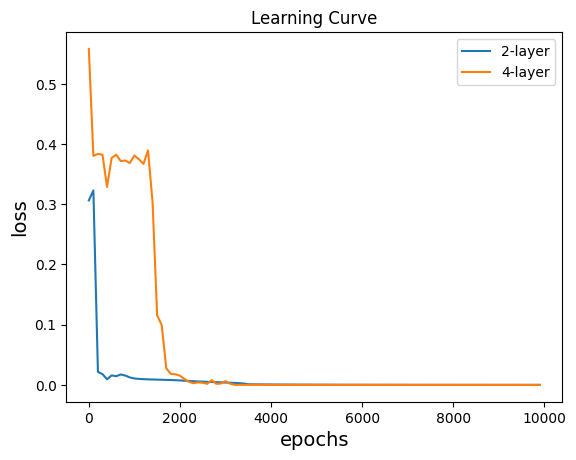

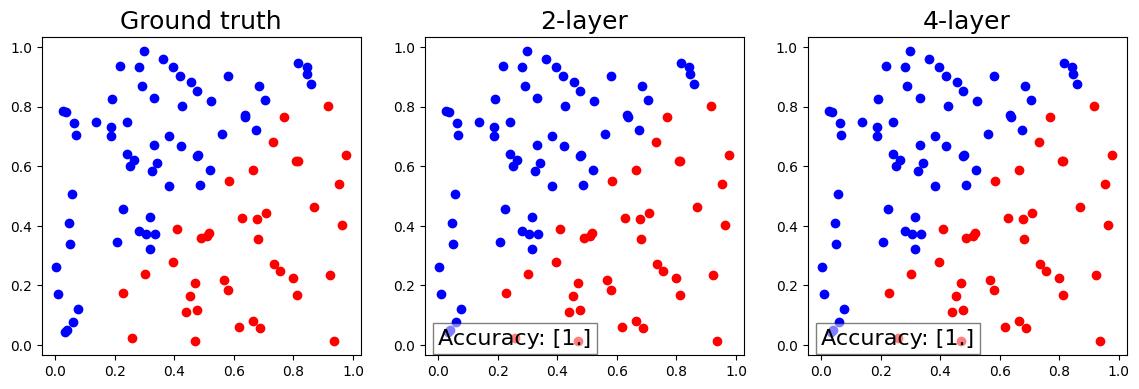

In [26]:
x,y =generate_linear()
epochs = 10000
model1  = Model()
model2 = Model_4layer()

compare(x,y,model1,model2,"2-layer","4-layer")

### XOR Data

--------- 2-layer Training -----------
epoch: 0 loss: 0.2622186702308113
epoch: 5000 loss: 0.00086176642810565
-------------2-layer Testing ------------
[[1.60304965e-04]
 [9.99996477e-01]
 [7.40681217e-05]
 [9.99996335e-01]
 [1.31526459e-04]
 [9.99994276e-01]
 [1.26720873e-03]
 [9.99955791e-01]
 [1.73518355e-02]
 [9.66200064e-01]
 [4.07913730e-02]
 [1.86563736e-02]
 [9.65399616e-01]
 [4.37007000e-03]
 [9.99918429e-01]
 [9.88286506e-04]
 [9.99979292e-01]
 [2.74213766e-04]
 [9.99983539e-01]
 [9.73217354e-05]
 [9.99983892e-01]]
------------2-layer Iteration---------------
Iter:1 |      Ground truth : [0] |   prediction : [0.0001603]
Iter:2 |      Ground truth : [1] |   prediction : [0.99999648]
Iter:3 |      Ground truth : [0] |   prediction : [7.40681217e-05]
Iter:4 |      Ground truth : [1] |   prediction : [0.99999633]
Iter:5 |      Ground truth : [0] |   prediction : [0.00013153]
Iter:6 |      Ground truth : [1] |   prediction : [0.99999428]
Iter:7 |      Ground truth : [0] |   predi

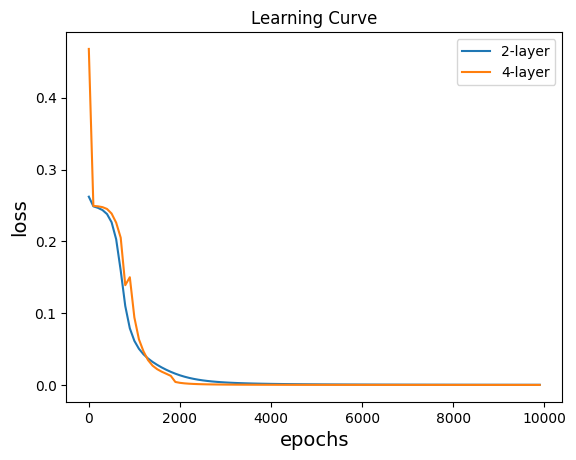

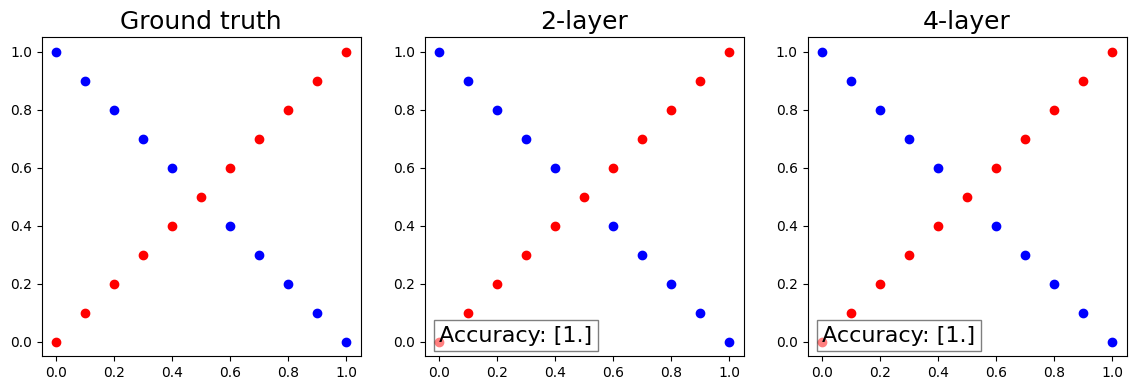

In [27]:
x_xor,y_xor =generate_XOR_easy()
epochs = 10000
model1  = Model()
model2 = Model_4layer()

compare(x_xor,y_xor,model1,model2,"2-layer","4-layer")

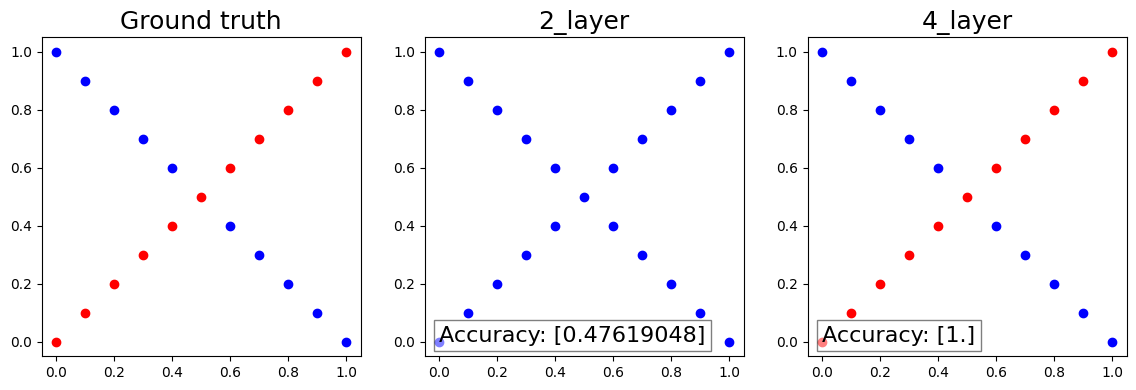

In [34]:
show_result_layer(x_xor,y_xor,y_pred_xor_2layer,y_pred_xor_4layer)

## No activate function

### Linear Data

--------- activate Training -----------
epoch: 0 loss: 0.22721953301225287
epoch: 5000 loss: 0.21390443487940675
epoch: 10000 loss: 0.19234297358634234
epoch: 15000 loss: 0.16010098696596808
epoch: 20000 loss: 0.12344959958612207
epoch: 25000 loss: 0.09336031683379517
epoch: 30000 loss: 0.07302074657197688
epoch: 35000 loss: 0.059827500354057775
epoch: 40000 loss: 0.051045279977017396
epoch: 45000 loss: 0.04493438490116351
epoch: 50000 loss: 0.04048259187567123
epoch: 55000 loss: 0.037101860196102135
epoch: 60000 loss: 0.034441952561661736
epoch: 65000 loss: 0.03228693370704184
epoch: 70000 loss: 0.030498572007046573
epoch: 75000 loss: 0.02898502436541022
epoch: 80000 loss: 0.02768310516947846
epoch: 85000 loss: 0.026547954324244637
epoch: 90000 loss: 0.02554682450799365
epoch: 95000 loss: 0.02465522328567747
-------------activate Testing ------------
[[0.98119059]
 [0.77659373]
 [0.00602091]
 [0.42815941]
 [0.97794435]
 [0.00213206]
 [0.98513326]
 [0.00488169]
 [0.00287895]
 [0.944978

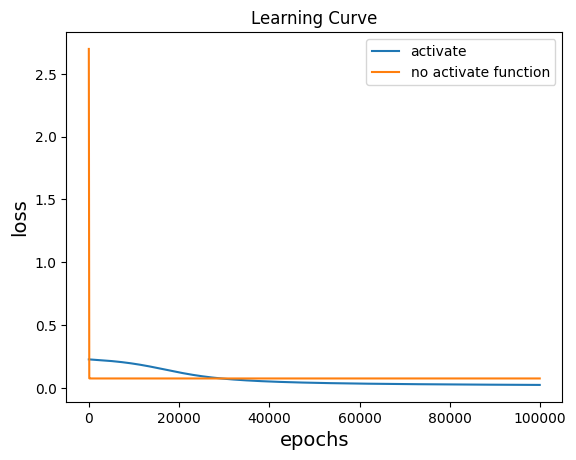

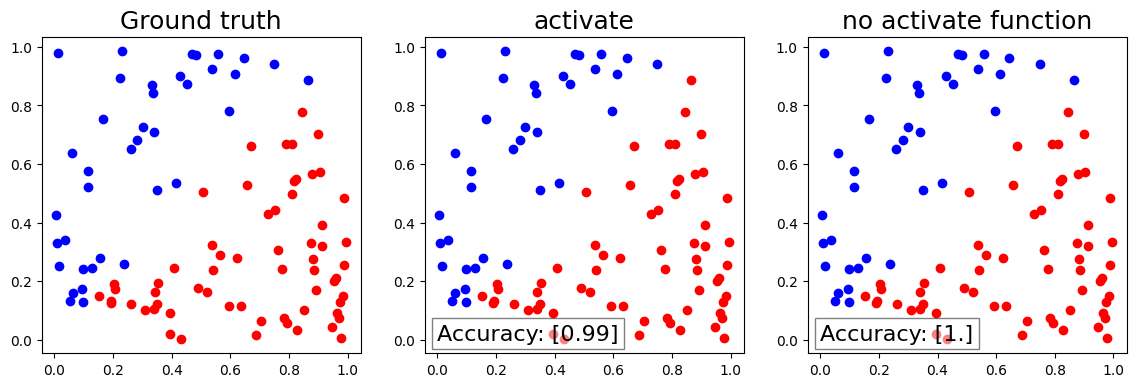

In [404]:
x,y =generate_linear()
epochs = 100000
model1 =Model(learning_rate= 1e-4)
model2 = Model(activate="None",learning_rate= 1e-4 )
# training
compare(x,y,model1,model2,"activate","no activate function")

### XOR Data

--------- activate Training -----------
epoch: 0 loss: 0.5168281118373462
epoch: 5000 loss: 0.24790108276157968
epoch: 10000 loss: 0.24515027983278323
epoch: 15000 loss: 0.2417863529377098
epoch: 20000 loss: 0.23688766579542708
epoch: 25000 loss: 0.2289142898182916
epoch: 30000 loss: 0.21522169040174383
epoch: 35000 loss: 0.19265104019920795
epoch: 40000 loss: 0.16197374752725957
epoch: 45000 loss: 0.1308302865922513
epoch: 50000 loss: 0.10539604971351406
epoch: 55000 loss: 0.08621272975566979
epoch: 60000 loss: 0.07174092877984388
epoch: 65000 loss: 0.06039892558637039
epoch: 70000 loss: 0.05104236325461492
epoch: 75000 loss: 0.04303962280580357
epoch: 80000 loss: 0.03613107322405605
epoch: 85000 loss: 0.03023122961364912
epoch: 90000 loss: 0.025287572770156648
epoch: 95000 loss: 0.021219682612315553
-------------activate Testing ------------
[[0.08790615]
 [0.96293155]
 [0.10201904]
 [0.95907859]
 [0.11778481]
 [0.95181328]
 [0.13215483]
 [0.93189267]
 [0.14196395]
 [0.70074727]
 [0.

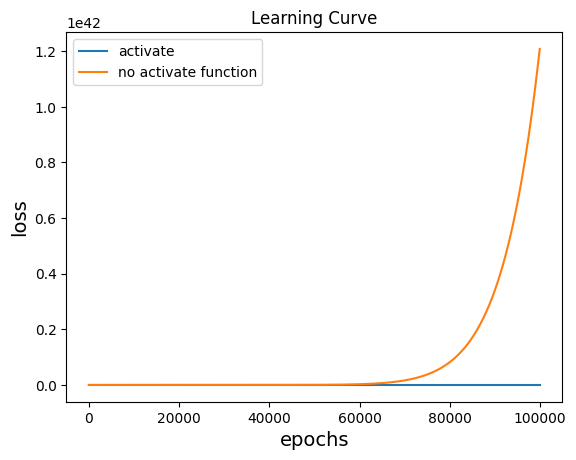

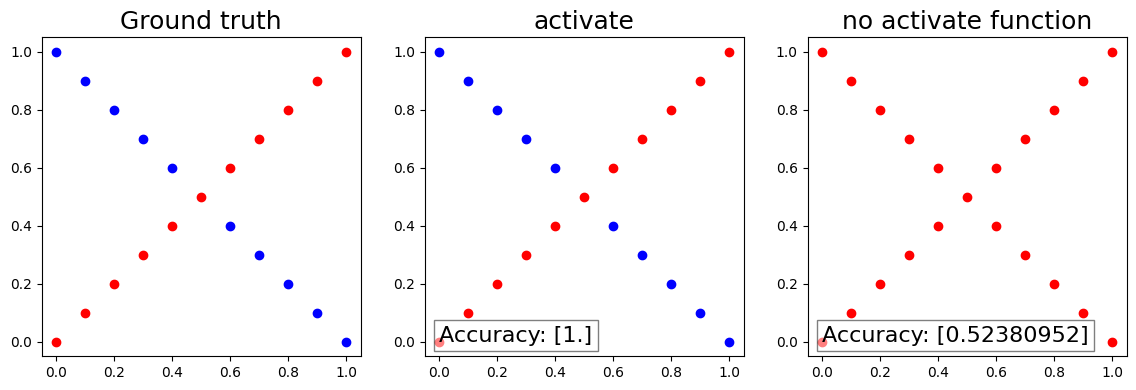

In [20]:
x_xor,y_xor =generate_XOR_easy()

epochs = 100000

model1 =Model( learning_rate= 0.001)
model2 = Model(activate="None",learning_rate= 0.001)
# training
compare(x_xor,y_xor,model1,model2,"activate","no activate function")

## Different hidden unit (5 vs 10)

### Linear Data

--------- 5 hidden unit Training -----------
epoch: 0 loss: 0.3865656115872245
epoch: 5000 loss: 0.2522315527667255
-------------5 hidden unit Testing ------------
[[0.48718733]
 [0.49322764]
 [0.49635748]
 [0.49634463]
 [0.48934496]
 [0.49508318]
 [0.48860121]
 [0.48853413]
 [0.49528333]
 [0.49575431]
 [0.48831852]
 [0.50096725]
 [0.48867793]
 [0.49925702]
 [0.49088284]
 [0.49020551]
 [0.49144654]
 [0.48823156]
 [0.50124902]
 [0.49622712]
 [0.48939027]
 [0.49667266]
 [0.48834411]
 [0.48823377]
 [0.49124697]
 [0.49583903]
 [0.49729812]
 [0.48285695]
 [0.49152549]
 [0.48731927]
 [0.4877064 ]
 [0.4877386 ]
 [0.48218588]
 [0.48916449]
 [0.49806389]
 [0.48938605]
 [0.48798119]
 [0.49149575]
 [0.48691194]
 [0.48714569]
 [0.48892114]
 [0.50074077]
 [0.49334243]
 [0.49853933]
 [0.48913646]
 [0.49261056]
 [0.48521855]
 [0.49294134]
 [0.49658035]
 [0.49682826]
 [0.49253721]
 [0.49524419]
 [0.50205241]
 [0.48051826]
 [0.49436305]
 [0.4926631 ]
 [0.49511759]
 [0.48633956]
 [0.48309377]
 [0.490791

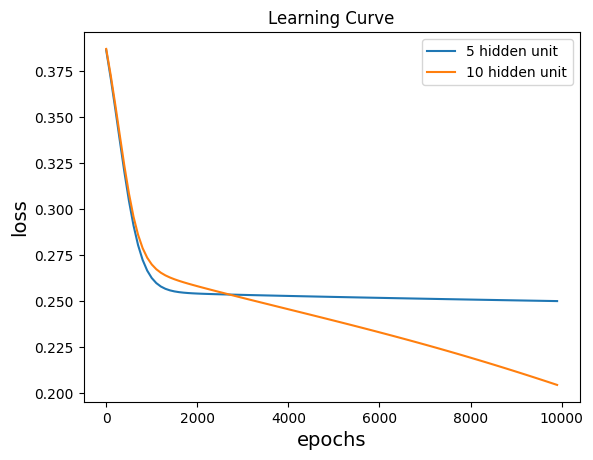

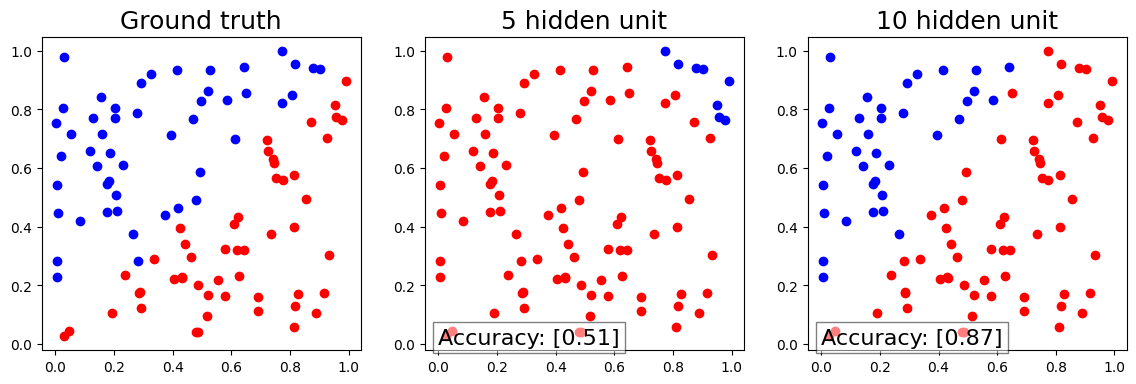

In [33]:
x,y =generate_linear()
epochs = 10000
model1 =Model(hidden1_size= 5,hidden2_size= 5,learning_rate= 1e-4)
model2 = Model(hidden1_size= 10,hidden2_size= 10,learning_rate= 1e-4 )
# training
compare(x,y,model1,model2,"5 hidden unit","10 hidden unit")

### XOR Data

--------- 5 hidden unit Training -----------
epoch: 0 loss: 0.40504710838252594
epoch: 5000 loss: 0.25018103532473746
-------------5 hidden unit Testing ------------
[[0.4960831 ]
 [0.48444714]
 [0.49206259]
 [0.48284987]
 [0.48804726]
 [0.48126081]
 [0.48409276]
 [0.47968151]
 [0.48024916]
 [0.47811326]
 [0.47655714]
 [0.47304565]
 [0.47501423]
 [0.46973153]
 [0.47348571]
 [0.4666205 ]
 [0.47197294]
 [0.46370913]
 [0.47047758]
 [0.46098729]
 [0.46900156]]
------------5 hidden unit Iteration---------------
Iter:1 |      Ground truth : [0] |   prediction : [0.4960831]
Iter:2 |      Ground truth : [1] |   prediction : [0.48444714]
Iter:3 |      Ground truth : [0] |   prediction : [0.49206259]
Iter:4 |      Ground truth : [1] |   prediction : [0.48284987]
Iter:5 |      Ground truth : [0] |   prediction : [0.48804726]
Iter:6 |      Ground truth : [1] |   prediction : [0.48126081]
Iter:7 |      Ground truth : [0] |   prediction : [0.48409276]
Iter:8 |      Ground truth : [1] |   prediction 

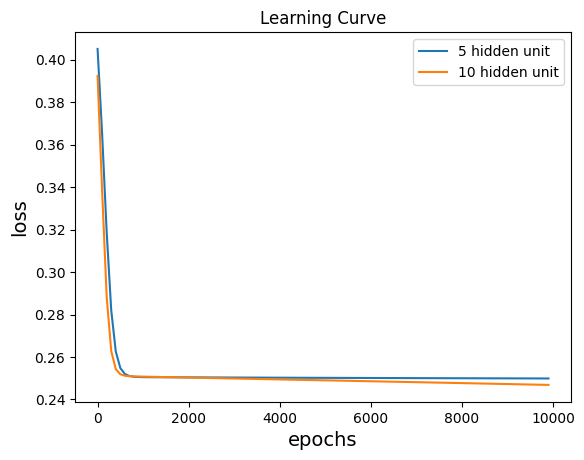

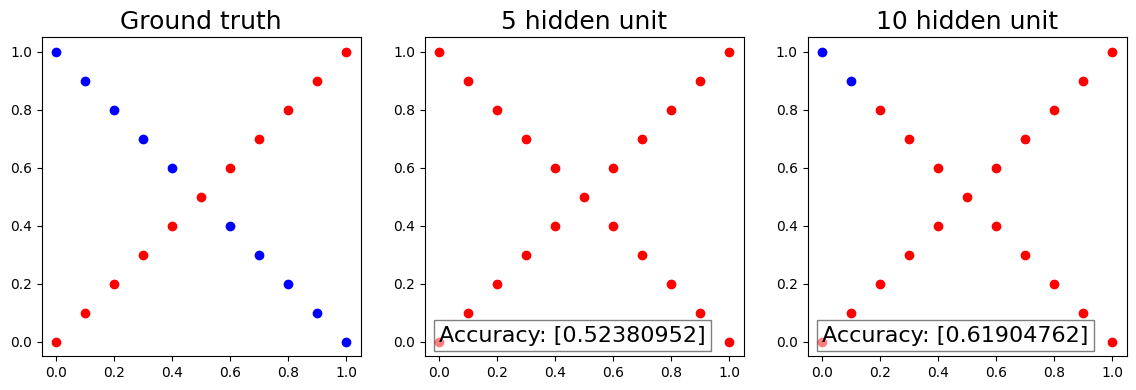

In [34]:
x_xor,y_xor =generate_XOR_easy()

epochs = 10000

model1 =Model( hidden1_size= 5,hidden2_size=5,learning_rate= 0.001)
model2 = Model(hidden1_size= 10,hidden2_size=10,learning_rate= 0.001)
# training
compare(x_xor,y_xor,model1,model2,"5 hidden unit","10 hidden unit")

# Extra

## Different activation function

### Linear Data

--------- Sigmoid Training -----------
epoch: 5000 loss: 0.27119563633580795
epoch: 10000 loss: 0.26207910194391587
epoch: 15000 loss: 0.25857047834362384
epoch: 20000 loss: 0.2556014636637462
epoch: 25000 loss: 0.2527508250901744
epoch: 30000 loss: 0.24997730168730722
epoch: 35000 loss: 0.24727088235014283
epoch: 40000 loss: 0.24462259942804593
epoch: 45000 loss: 0.24202170655791336
epoch: 50000 loss: 0.23945556236402615
epoch: 55000 loss: 0.23691009161183618
epoch: 60000 loss: 0.23437049635805995
epoch: 65000 loss: 0.23182200980157713
epoch: 70000 loss: 0.22925053695251218
epoch: 75000 loss: 0.22664309812818137
epoch: 80000 loss: 0.2239880597751507
epoch: 85000 loss: 0.22127518644718652
epoch: 90000 loss: 0.2184955742920081
epoch: 95000 loss: 0.2156415329071036
epoch: 100000 loss: 0.21270647416249966
-------------Sigmoid Testing ------------
[[0.56564595]
 [0.46674062]
 [0.54005802]
 [0.57650893]
 [0.59367376]
 [0.5578817 ]
 [0.47108873]
 [0.60852546]
 [0.63591265]
 [0.54990281]
 [0.

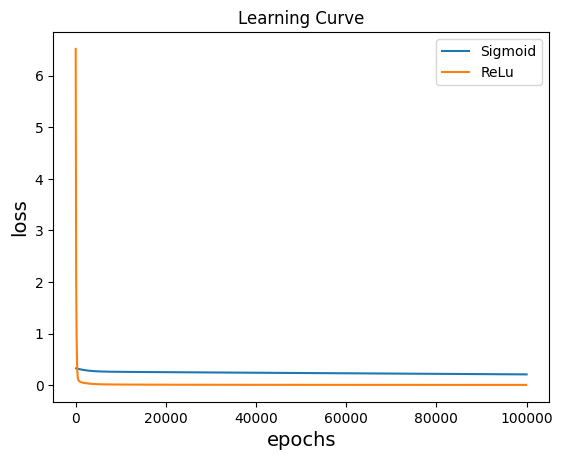

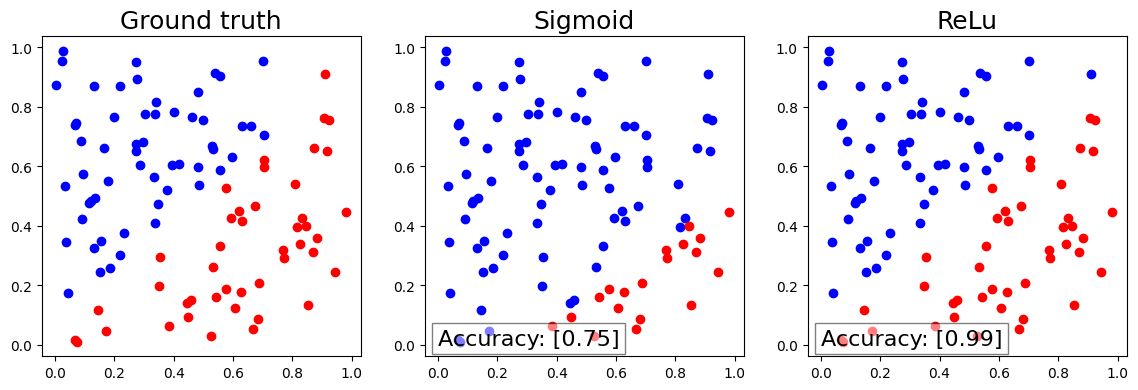

In [41]:
x,y =generate_linear()
epochs = 100000
model1 =Model(activate="Sigmoid",learning_rate=1e-5)
model2 = Model(activate= "ReLu" ,learning_rate=1e-5)
# training
compare(x,y,model1,model2,"Sigmoid","ReLu")

### XOR Data

--------- Sigmoid Training -----------
epoch: 5000 loss: 0.24873078927809966
epoch: 10000 loss: 0.2486057814529954
epoch: 15000 loss: 0.24853815255366749
epoch: 20000 loss: 0.24849726104286166
epoch: 25000 loss: 0.2484688401116168
epoch: 30000 loss: 0.24844626602085051
epoch: 35000 loss: 0.2484264681262634
epoch: 40000 loss: 0.24840802379583002
epoch: 45000 loss: 0.24839027377184567
epoch: 50000 loss: 0.24837291211080886
epoch: 55000 loss: 0.24835579630843943
epoch: 60000 loss: 0.248338859439055
epoch: 65000 loss: 0.2483220695190823
epoch: 70000 loss: 0.24830541071935555
epoch: 75000 loss: 0.24828887468206376
epoch: 80000 loss: 0.24827245650940308
epoch: 85000 loss: 0.24825615291142356
epoch: 90000 loss: 0.24823996135144155
epoch: 95000 loss: 0.24822387965210257
epoch: 100000 loss: 0.2482079058140058
-------------Sigmoid Testing ------------
[[0.52697919]
 [0.48172681]
 [0.51672794]
 [0.47998836]
 [0.50640529]
 [0.47851472]
 [0.4962217 ]
 [0.4773701 ]
 [0.48625014]
 [0.47664449]
 [0.47

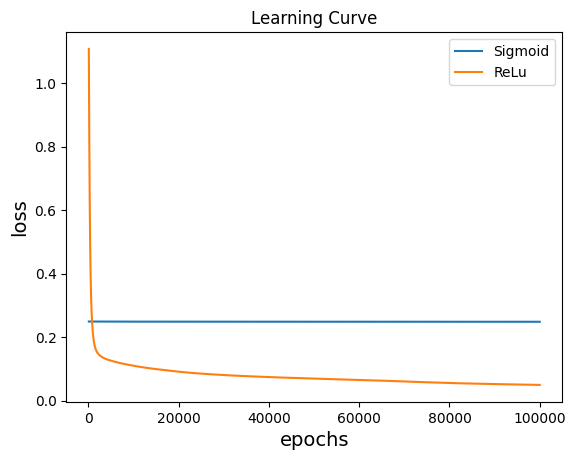

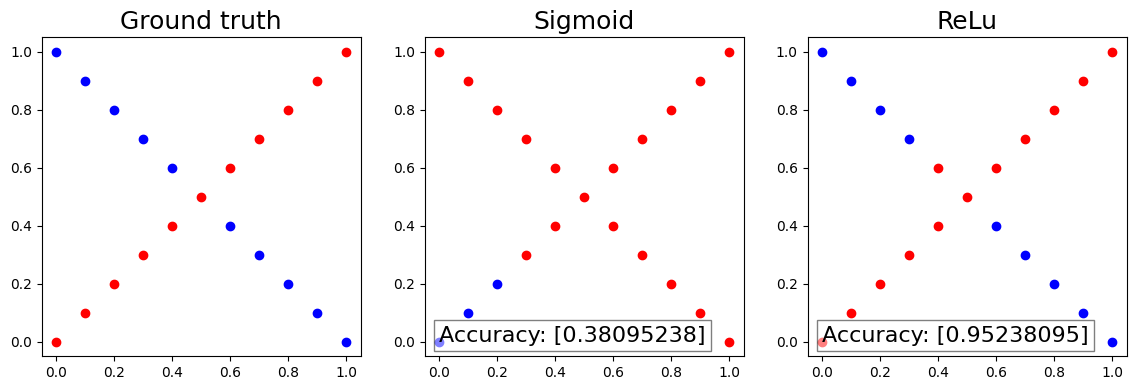

In [44]:
x_xor,y_xor =generate_XOR_easy()
epochs = 100000
model1 =Model(activate="Sigmoid",learning_rate=1e-5)
model2 = Model(activate= "ReLu" ,learning_rate=1e-5)
# training
compare(x_xor,y_xor,model1,model2,"Sigmoid","ReLu")

## Convolutional Layers

In [ ]:
def convolution2d(x, kernel, bias, stride=1, padding=0):
    #填充值為0
    x_padded = np.pad(x, ((padding, padding), (padding, padding)), mode='constant')
    #獲得padding後的shape
    x_h, x_w = x_padded.shape
    k_h, k_w = kernel.shape
    out_h = (x_h - k_h) // stride + 1
    out_w = (x_w - k_w) // stride + 1
    out = np.zeros((out_h, out_w))

    for i in range(0, out_h):
        for j in range(0, out_w):
            region = x_padded[i*stride:i*stride+k_h, j*stride:j*stride+k_w]
            out[i, j] = np.sum(region * kernel) + bias

    return out

### Linear Data

## Different Optimizer

### Linear Data

--------- SGD Training -----------
epoch: 5000 loss: 0.27766524016243044
epoch: 10000 loss: 0.2550525888968806
epoch: 15000 loss: 0.24827752384259733
epoch: 20000 loss: 0.2436768349286567
epoch: 25000 loss: 0.23937163937744138
epoch: 30000 loss: 0.23523694397782313
epoch: 35000 loss: 0.2312382906441758
epoch: 40000 loss: 0.22734696534705875
epoch: 45000 loss: 0.2235366829213338
epoch: 50000 loss: 0.21978346215537845
-------------SGD Testing ------------
[[0.36143813]
 [0.37429765]
 [0.34780479]
 [0.37778554]
 [0.37112014]
 [0.39077835]
 [0.38152032]
 [0.35417235]
 [0.35584092]
 [0.36105607]
 [0.36551695]
 [0.38857287]
 [0.40835836]
 [0.40341146]
 [0.37113761]
 [0.40581488]
 [0.36779507]
 [0.36241367]
 [0.37656952]
 [0.38683205]
 [0.39587182]
 [0.35296599]
 [0.36641799]
 [0.36686544]
 [0.36236608]
 [0.37831567]
 [0.3566347 ]
 [0.35176603]
 [0.39415106]
 [0.35496833]
 [0.4162962 ]
 [0.39272743]
 [0.34617484]
 [0.40528137]
 [0.35608696]
 [0.36443592]
 [0.37511812]
 [0.3559018 ]
 [0.410328

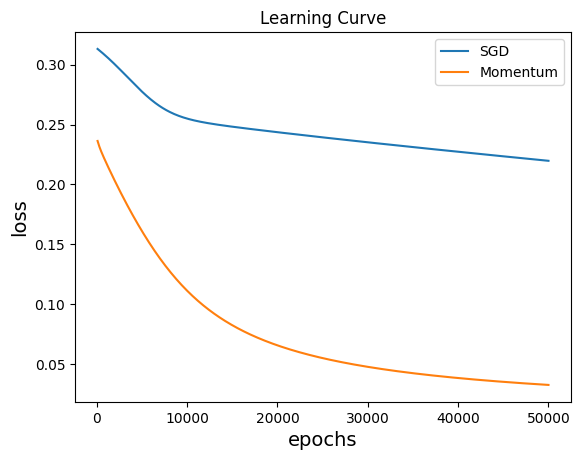

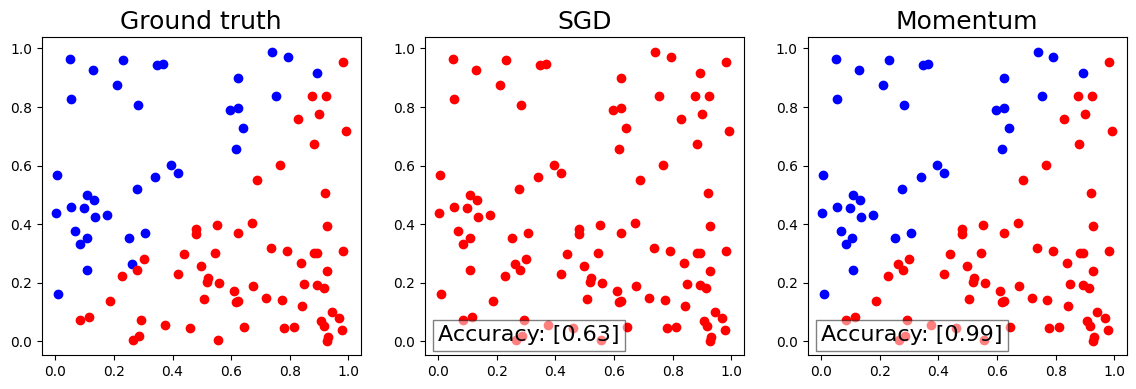

In [50]:
x,y =generate_linear()
epochs = 50000
model1 =Model(optimizer="SGD",learning_rate=1e-5)
model2 = Model(optimizer="Momentum" ,learning_rate=1e-5)
# training
compare(x,y,model1,model2,"SGD","Momentum")

### XOR Data

--------- SGD Training -----------
epoch: 5000 loss: 0.25109008342981526
epoch: 10000 loss: 0.2508625843795452
epoch: 15000 loss: 0.25071962050348084
epoch: 20000 loss: 0.2505785574089214
epoch: 25000 loss: 0.2504390028189353
epoch: 30000 loss: 0.25030067047780186
epoch: 35000 loss: 0.2501633133565002
epoch: 40000 loss: 0.2500267231805351
epoch: 45000 loss: 0.2498907297631014
epoch: 50000 loss: 0.24975519992264983
-------------SGD Testing ------------
[[0.47434195]
 [0.4326882 ]
 [0.47414442]
 [0.44034437]
 [0.4741799 ]
 [0.44846046]
 [0.47437332]
 [0.4569961 ]
 [0.47465891]
 [0.46587608]
 [0.47498287]
 [0.47530297]
 [0.48415887]
 [0.47558687]
 [0.49321925]
 [0.47581038]
 [0.50197216]
 [0.47595594]
 [0.51024088]
 [0.47601155]
 [0.51788222]]
------------SGD Iteration---------------
Iter:1 |      Ground truth : [0] |   prediction : [0.47434195]
Iter:2 |      Ground truth : [1] |   prediction : [0.4326882]
Iter:3 |      Ground truth : [0] |   prediction : [0.47414442]
Iter:4 |      Ground

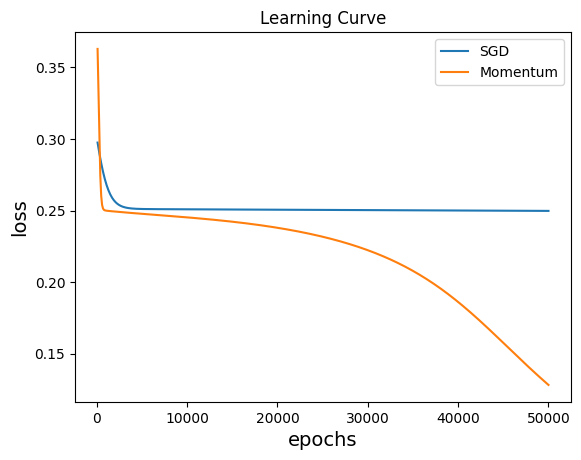

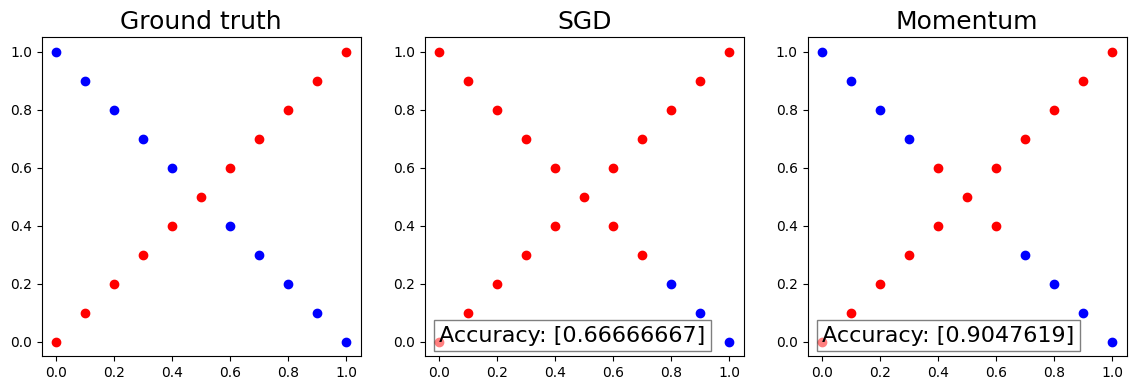

In [53]:
x_xor,y_xor =generate_XOR_easy()
epochs = 50000
model1 =Model(optimizer="SGD",learning_rate=1e-4)
model2 = Model(optimizer="Momentum" ,learning_rate=1e-4)
# training
compare(x_xor,y_xor,model1,model2,"SGD","Momentum")